In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def stretched_exp_Cipelletti(x, dr):
    return np.exp(-2.*np.sqrt(3.)*np.power((x*dr), 1.5)/3.)
    #return np.exp(-np.power((x*dr), 1.5))

In [2]:
# indices: Qs, cycles
# ampl = 3%
cycles = np.array([1,2,3,4,5,6,7,8,9,10]) # (~)
Qs_determ = 10*np.array([0.00092, 0.00233, 0.00373, 0.00514, 0.00654, 0.00795, 0.00935, \
      0.01076, 0.01216, 0.01357, 0.01497, 0.01638, 0.01778, 0.01919, 0.0206]) # (inverse nm)
# shape: (15, 10)

determ = np.loadtxt("deterministic_normalized.txt", delimiter=',')
print(determ.shape)

(15, 10)


/tmp/ipykernel_940306/2148632991.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 500x300 with 0 Axes>

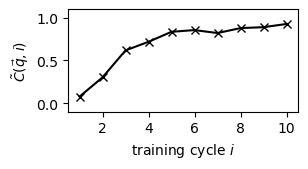

<Figure size 640x480 with 0 Axes>

In [3]:
# get fits for deterministic data (for Fig. 3)

x = np.array(Qs_determ)
popt_array = np.zeros((len(cycles)))

cmap=matplotlib.colormaps['plasma']

fig, ax = plt.subplots(1, 1, figsize=(5,3))
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
for ii in range(len(cycles)):
    popt, pcov = curve_fit(stretched_exp_Cipelletti, x, determ[:,ii], bounds=([0], [700]))
    plt.plot(x, determ[:,ii], color=cmap(ii/len(cycles)))
    testx = np.linspace(x[0],x[-1],num=100)
    plt.plot(testx, stretched_exp_Cipelletti(testx, popt[0]), '-', color='k', alpha=0.5)
    popt_array[ii] = popt[0]
dr_determ = popt_array
plt.legend()
plt.xlabel("Q (inv nm)")
plt.ylabel("best fit dr")
#plt.show()
plt.clf()

# Make plot for Fig. 2b

fig, ax = plt.subplots(1, 1, figsize=(3.18,1.8))
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)

plt.plot(cycles, determ[3, :], '-x', color='k')
plt.ylim([-0.1,1.1])
plt.xlim([0.5,10.5])
ax.set_xlabel(r"training cycle $i$", size=10)
ax.set_ylabel(r"$\tilde{C}(\vec{q},i)$", size=10)
ax.set_yticks([0,0.5,1])
ax.set_xticks([2,4,6,8,10])
plt.tight_layout()
#plt.savefig("C_determ_training.pdf")
plt.show()
plt.clf()

In [119]:
# indices: epochs, Qs, cycles within epoch

epochs = np.array([1,2,3,4,5,6,7,8]) # (~)
Qs_rand = 10*np.array([0.00092, 0.00094, 0.00234, 0.00377, 0.0052, 0.00662, 0.00804, 0.00947, \
      0.01089, 0.01232, 0.01374, 0.01517, 0.01659, 0.01802, 0.01944]) # (inverse nm)
cycles = np.array([1,2,3,4,5,6,7,8,9,10]) # (~)

# shape: (8, 15, 10)

rand = np.reshape(np.loadtxt("random_normalized.txt", delimiter=','), (8, 15, 10))
rand = np.delete(rand, 1, axis=1) # gets rid of near-duplicate Q
Qs_rand = 10*np.array([0.00092, 0.00234, 0.00377, 0.0052, 0.00662, 0.00804, 0.00947, \
      0.01089, 0.01232, 0.01374, 0.01517, 0.01659, 0.01802, 0.01944])

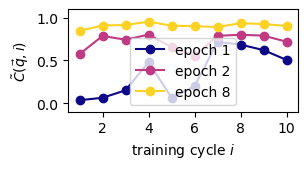

<Figure size 640x480 with 0 Axes>

In [120]:
# Make plot for Fig. 2d

fig, ax = plt.subplots(1, 1, figsize=(3.18,1.8))

matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)
cmap=matplotlib.colormaps['plasma']

aa = 0
for ii in [0,1,7]:
    plt.plot(cycles, rand[ii, 3, :], '-o', color=cmap(aa/2.2), label="epoch " + str(ii+1))
    aa += 1
plt.legend()
plt.ylim([-0.1,1.1])
plt.xlim([0.5,10.5])
ax.set_xlabel(r"training cycle $i$", size=10)
ax.set_ylabel(r"$\tilde{C}(\vec{q},i)$", size=10)
ax.set_yticks([0,0.5,1])
ax.set_xticks([2,4,6,8,10])
plt.tight_layout()
#plt.savefig("C_random_training.pdf")
plt.show()
plt.clf()

<>:28: SyntaxWarning: invalid escape sequence '\D'
<>:28: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_692375/4176804884.py:28: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta r$ (nm$^{-1}$)", fontsize=10)


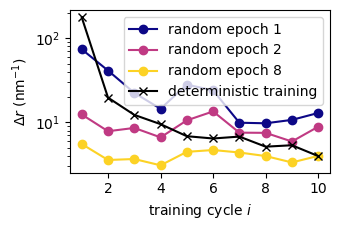

<Figure size 640x480 with 0 Axes>

In [125]:
# make plots for Figure 3b

x = np.array(Qs_rand)
popt_array = np.zeros((len(epochs), len(cycles)))

for ii in range(len(epochs)):
    for jj in range(len(cycles)):
        y = np.array(rand[ii,:,jj])
        testx = np.linspace(np.min(x), np.max(x), num=100)
        popt, pcov = curve_fit(stretched_exp_Cipelletti, x, y, bounds=([0], [700]))
        popt_array[ii,jj] = popt[0]
        

cmap=matplotlib.colormaps['plasma']
fig, ax = plt.subplots(1, 1, figsize=(3.5,2.4))
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)

aa = 0
for ii in [0,1,7]:
    plt.plot(np.array(cycles), popt_array[ii, :], '-o', color=cmap(aa/2.2), label="random epoch " + str(ii+1))
    aa += 1
plt.plot(np.array(cycles), dr_determ, 'x-', color='k', label="deterministic training")
plt.legend(fontsize=10)
#plt.xscale("log")
plt.yscale("log")
plt.xlabel("training cycle $i$", fontsize=10)
plt.ylabel("$\Delta r$ (nm$^{-1}$)", fontsize=10)
plt.tight_layout()
plt.savefig("best_fit_dr.pdf")
plt.show()
plt.clf()

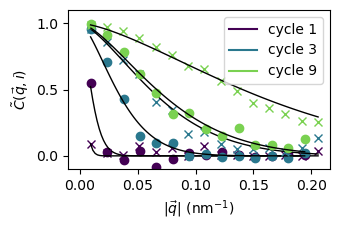

<Figure size 640x480 with 0 Axes>

In [141]:
# plot Fig. 3a

cmap = matplotlib.colormaps['viridis']

fig, ax = plt.subplots(1, 1, figsize=(3.5,2.4))
matplotlib.rc('xtick', labelsize=10)
matplotlib.rc('ytick', labelsize=10)

testx_rand = np.linspace(np.min(Qs_rand), np.max(Qs_rand), num=100)
testx_determ = np.linspace(np.min(Qs_determ), np.max(Qs_determ), num=100)

aa = 0
for ii in [0,2,8]:
    plt.plot(Qs_rand, rand[0, :, ii], 'o', color=cmap(aa/2.5))
    plt.plot(testx_rand, stretched_exp_Cipelletti(testx, popt_array[0, ii]), '-', color="k", linewidth=1)
    plt.plot(Qs_determ, determ[:, ii], 'x', color=cmap(aa/2.5))
    plt.plot(testx_determ, stretched_exp_Cipelletti(testx, dr_determ[ii]), '-', color="k", linewidth=1)
    plt.plot(0, 1.5, '-', color=cmap(aa/2.5), label="cycle " + str(ii+1))
    aa += 1
plt.legend(fontsize=10)
plt.ylim([-0.1,1.1])
ax.set_xlabel(r"|$\vec{q}$| (nm$^{-1}$)", size=10)
ax.set_ylabel(r"$\tilde{C}(\vec{q},i)$", size=10)
ax.set_yticks([0,0.5,1])
plt.tight_layout()
plt.savefig("C_vs_q.pdf")
plt.show()
plt.clf()